In [1]:
import pandas as pd
import random

In [2]:
class SimpleRLProductionSystem:
    def __init__(self, max_inventory, max_production, max_demand, epsilon=0.1):
        self.max_inventory = max_inventory
        self.max_production = max_production
        self.max_demand = max_demand
        self.epsilon = epsilon
        self.data = pd.DataFrame(columns=['State', 'Demand', 'Action', 'Reward'])
        self._initialize_data()

    def _initialize_data(self):
        rows = []
        for state in range(self.max_inventory + 1):
            for demand in range(self.max_demand + 1):
                for action in range(self.max_production + 1):
                    rows.append({'State': state, 'Demand': demand, 'Action': action, 'Reward': float('-inf')})
        self.data = pd.concat([self.data, pd.DataFrame(rows)], ignore_index=True)

    def choose_action(self, state, demand):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.max_production)  # Explore
        else:
            state_demand_data = self.data[(self.data['State'] == state) & (self.data['Demand'] == demand)]
            return state_demand_data.loc[state_demand_data['Reward'].idxmax()]['Action']  # Exploit

    def get_reward(self, state, action, demand):
        potential_inventory = state + action
        if potential_inventory > self.max_inventory:
            return -20  # Penalize for exceeding the capacity
        else:
            if potential_inventory >= demand:
                return 10 - (potential_inventory - demand)  # Positive reward for meeting demand, less for overproduction
            else:
                return -10 + (potential_inventory - demand)  # Negative reward for underproduction

    def update_data(self, state, demand, action, reward):
        row_index = self.data[(self.data['State'] == state) & (self.data['Demand'] == demand) & (self.data['Action'] == action)].index
        if self.data.at[row_index[0], 'Reward'] < reward:
            self.data.at[row_index[0], 'Reward'] = reward

    def simulate(self, episodes):
        for _ in range(episodes):
            state = random.randint(0, self.max_inventory) 
            demand = random.randint(0, self.max_demand)  # Randomly chosen demand
            action = self.choose_action(state, demand)
            reward = self.get_reward(state, action, demand)
            self.update_data(state, demand, action, reward)

    def evaluate_agent(self, episodes):
        total_reward = 0
        demand_met_count = 0
        episode_data = []

        for episode in range(episodes):
            state = random.randint(0, self.max_inventory)
            demand = random.randint(0, self.max_demand)
            action = self.choose_action_test(state, demand)
            reward = self.get_reward(state, action, demand)
            total_reward += reward

            if state + action >= demand:
                demand_met_count += 1

            # Store state, demand, action, and reward for each episode
            episode_data.append((episode, state, demand, action, reward))
            # Printing the demand and action for each episode
            #print(f"Episode {episode + 1}: Demand = {demand}, Action = {action}, State = {state}")

        average_reward = total_reward / episodes
        demand_met_rate = demand_met_count / episodes

        return average_reward, demand_met_rate, episode_data

    
    def choose_action_test(self, state, demand):
            state_demand_data = self.data[(self.data['State'] == state) & (self.data['Demand'] == demand)]
            return state_demand_data.loc[state_demand_data['Reward'].idxmax()]['Action']  # Exploit

In [4]:
# Example usage
system = SimpleRLProductionSystem(max_inventory=5, max_production=5, max_demand=5)
system.simulate(episodes=200000)
print(system.data)
system.data.to_csv('file1.csv')

    State Demand Action  Reward
0       0      0      0    10.0
1       0      0      1     9.0
2       0      0      2     8.0
3       0      0      3     7.0
4       0      0      4     6.0
..    ...    ...    ...     ...
211     5      5      1   -20.0
212     5      5      2   -20.0
213     5      5      3   -20.0
214     5      5      4   -20.0
215     5      5      5   -20.0

[216 rows x 4 columns]


In [14]:
# Evaluate the trained agent and observe output directly from the method
evaluation_episodes = 25  # Set to a smaller number for demonstration
average_reward, demand_met_rate, Episode_data = system.evaluate_agent(evaluation_episodes)

# Print summary statistics
print(f"\nAverage Reward over {evaluation_episodes} evaluation episodes: {average_reward}")
print(f"Demand Met Rate over {evaluation_episodes} evaluation episodes: {demand_met_rate:.2%}")
print(f"Episode data: {Episode_data}")
#episode, state, demand, action, reward


Average Reward over 25 evaluation episodes: 9.28
Demand Met Rate over 25 evaluation episodes: 100.00%
Episode data: [(0, 2, 4, 2, 10), (1, 3, 3, 0, 10), (2, 1, 3, 2, 10), (3, 2, 4, 2, 10), (4, 4, 2, 0, 8), (5, 1, 1, 0, 10), (6, 3, 4, 1, 10), (7, 4, 2, 0, 8), (8, 2, 3, 1, 10), (9, 1, 3, 2, 10), (10, 5, 2, 0, 7), (11, 5, 0, 0, 5), (12, 5, 4, 0, 9), (13, 5, 3, 0, 8), (14, 0, 5, 5, 10), (15, 2, 5, 3, 10), (16, 1, 2, 1, 10), (17, 4, 1, 0, 7), (18, 3, 3, 0, 10), (19, 0, 3, 3, 10), (20, 0, 2, 2, 10), (21, 5, 5, 0, 10), (22, 0, 3, 3, 10), (23, 3, 4, 1, 10), (24, 0, 2, 2, 10)]


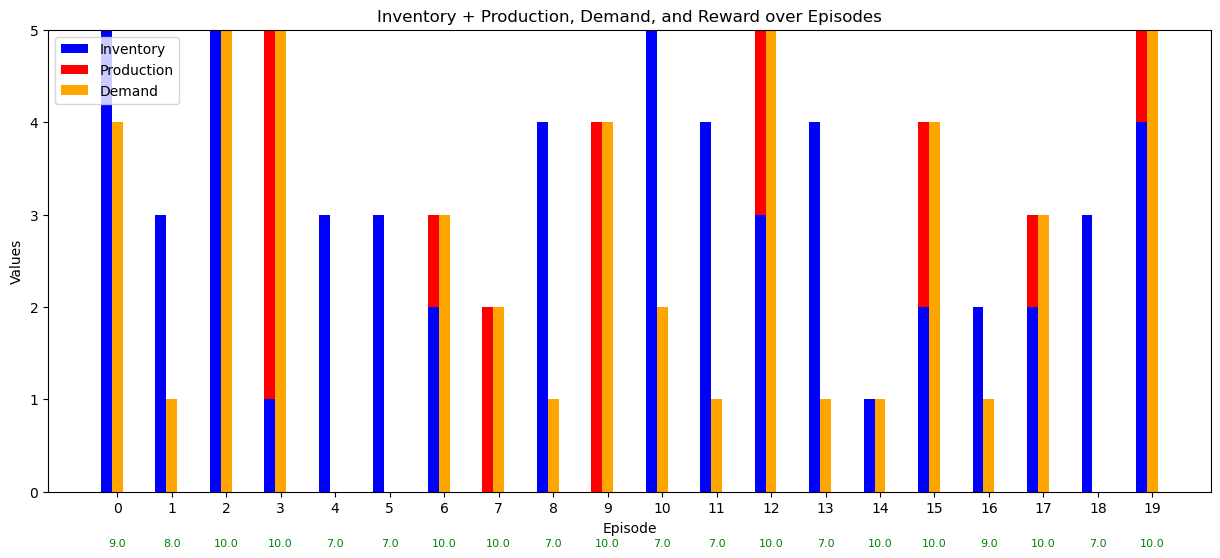

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(20)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 6))
width = 0.2  # Width of the bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    # State + Action stacked bar
    plt.bar(i - width, df.loc[i, 'State'], width, label='Inventory' if i == 0 else "", color='blue')
    plt.bar(i - width, df.loc[i, 'Action'], width, bottom=df.loc[i, 'State'], label='Production' if i == 0 else "", color='red')

    # Demand bar
    plt.bar(i, df.loc[i, 'Demand'], width, label='Demand' if i == 0 else "", color='orange')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, -0.5, f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Inventory + Production, Demand, and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()
